<a href="https://colab.research.google.com/github/xc308/Understanding-Transformer-Attention-Weights/blob/main/Masked_Multi_head_Attention_Weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim:

- Compute the attention weight vector for multiple heads and apply masking to prevent the model from "looking into the future."

- 4 attention heads per transformer layer block

In [1]:
# Install the custom package for this course.
!pip install orbax-checkpoint==0.11.21
!pip install "git+https://github.com/google-deepmind/ai-foundations.git@main"

import jax # For working with vectors and matrices.
import jax.numpy as jnp # For working with vectors and matrices.
from ai_foundations import generation # For prompting the Gemma model.
from ai_foundations import visualizations # For visualizing attention weights.
from ai_foundations import attention # For working with Q,K,V matrices.

  Cloning https://github.com/google-deepmind/ai-foundations.git (to revision main) to /tmp/pip-req-build-lqzsq95l
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/ai-foundations.git /tmp/pip-req-build-lqzsq95l
  Resolved https://github.com/google-deepmind/ai-foundations.git to commit 524d6114bbce631dafc00ba3496607a0bc60c804
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Install the custom package for this course.
!pip install orbax-checkpoint==0.11.21
!pip install "git+https://github.com/google-deepmind/ai-foundations.git@main"

import jax # For working with vectors and matrices.
import jax.numpy as jnp # For working with vectors and matrices.
from ai_foundations import generation # For prompting the Gemma model.
from ai_foundations import visualizations # For visualizing attention weights.
from ai_foundations import attention # For working with Q,K,V matrices.

  Cloning https://github.com/google-deepmind/ai-foundations.git (to revision main) to /tmp/pip-req-build-e1356n1q
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/ai-foundations.git /tmp/pip-req-build-e1356n1q
  Resolved https://github.com/google-deepmind/ai-foundations.git to commit 524d6114bbce631dafc00ba3496607a0bc60c804
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
from ai_foundations.feedback.course_4 import attention as attention_feedback

In [3]:
# Initialize caches for prompts.
previous_prompt = None
previous_prompt2 = None

# Load special version of the Gemma-1B model that provides access to attention
# weights and QKV matrices.
print("Loading Gemma-1B...")
model = generation.load_gemma("Gemma-1B-AttentionWeight")
print("Loaded Gemma-1B.")

Loading Gemma-1B...
Loaded Gemma-1B.


Generated text: Jide was hungry so she went looking for food


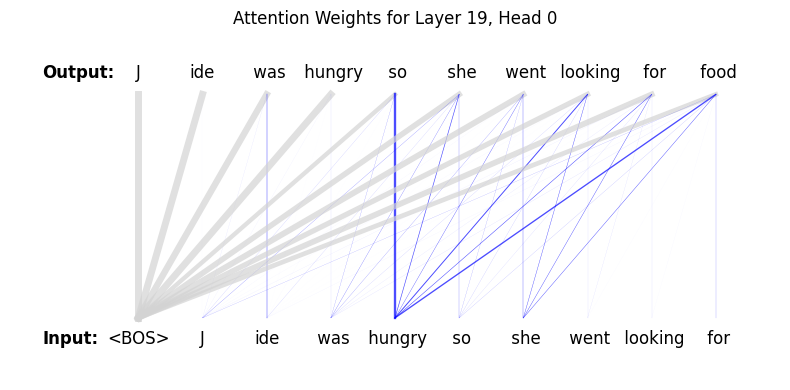

In [7]:
# @title Visualize attention weights (reference implementation)
from IPython.display import clear_output

layer = 19  # @param {type:"slider", min: 0, max: 25}

head = 0  # @param {type:"slider", min: 0, max: 3}

prompt = "Jide was hungry so she went looking for"  # @param {type: "string"}
# @markdown Check the following box to display the attention weights for all tokens, not just for the generated one:
show_all_weights = True  # @param {type:"boolean"}

if prompt != previous_prompt:
    (
        output_text,
        next_token_logits,
        tokenizer,
        attention_weights,
        _,
        qkv_dict,
    ) = generation.prompt_attention_transformer_model(
        prompt, model, sampling_mode="greedy"
    )
    tokens = [tokenizer.tokens[t] for t in tokenizer.encode(output_text)]
    previous_prompt = prompt

print(f"Generated text: {output_text}")

visualizations.visualize_attention(
    tokens,
    attention_weights[f"layer_{layer}"],
    layer,
    head=head,
    min_line_thickness=0,
    max_line_thickness=5,
    show_all_weights=show_all_weights,
)

- Mask attention
- Stack matrics
- Compute raw logits
- apply attention mask
- compute attention weights
- compute attention output

**Compute the Attention Mask**

- The attention mask is a square triangular matrix where every value on or below the diagonal is 1 and every value above the diagonal is 0.

In [8]:
def compute_attention_mask(num_tokens: int) -> jax.Array:
    """Computes the attention mask for an input of length `num_tokens`.

    Args:
      num_tokens: Number of tokens in the input.

    Returns:
      attention_mask: A diagonal matrix indicating which attention logit should
        be masked. Shape: (num_tokens, num_tokens).
    """

    attention_mask = jnp.tri(num_tokens, k = 0)  # Compute the attention mask here.

    return attention_mask

print(f"Attention mask for input length 5:\n {compute_attention_mask(5)}")
print(f"\nAttention mask for input length 6:\n {compute_attention_mask(6)}")

Attention mask for input length 5:
 [[1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1.]]

Attention mask for input length 6:
 [[1. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1.]]


**Stack Matrices**

- tack these matrices together such that you obtain a 3-dimensional tensor

    - The first dimension should correspond to the head,
    - the second dimension to the token index,
    - and the third dimension should be individual components of the vectors.

In [9]:
def stack_matrices(
    qkv_dict: dict[str, dict[str, jax.Array]], layer: int
) -> tuple[jax.Array, jax.Array, jax.Array]:
    """Retrieves the list of query, key, and value matrices for each head and
        stacks them into a multi-dimensional tensor.

    Args:
      qkv_dict: A dictionary containing the raw query, key, and value
        projections for all layers. The keys are strings identifying the layers
        and matrix types, and values are the corresponding JAX arrays.
      layer: The specific layer for which to compute the attention weights.

    Returns:
      query_proj: Query projection tensor.
        Shape: (num_heads, num_tokens, dim_k).
      key_proj: Key projection tensor. Shape: (num_heads, num_tokens, dim_k).
      value_proj: Value projection tensor.
        Shape: (num_heads, num_tokens, dim_v).
    """

    # Passing `head=None` results in `get_qkv_matrices` returning lists of
    # `num_heads` projection matrices rather than just an individual projection
    # matrix.
    (
        query_proj_list,
        key_proj_list,
        value_proj_list
    ) = attention.get_qkv_matrices(
        qkv_dict, layer, head=None
    )

    # Stack the query, key, and value projection matrices here:
    query_proj = jnp.stack(query_proj_list, axis=0)
    key_proj = jnp.stack(key_proj_list, axis=0)
    value_proj = jnp.stack(value_proj_list, axis=0)


    return query_proj, key_proj, value_proj

In [10]:
def stack_matrices(
        qkv_dict: dict[str, dict[str, jax.Array]], layer: int
) -> tuple[jax.Array, jax.Array, jax.Array]:

    (   query_proj_list,
        key_proj_list,
        value_proj_list
     ) = attention.get_qkv_matrices(
        qkv_dict, layer, head = None
    )

    query_proj = jnp.stack(query_proj_list, axis = 0)
    key_proj = jnp.stack(key_proj_list, axis=0)
    value_proj = jnp.stack(value_proj_list, axis = 0)

    return query_proj, key_proj, value_proj



In [15]:
attention_feedback.test_stack_matrices(stack_matrices, qkv_dict)

✅ All tests passed. Your implementation is looking good.


**Compute raw logits**

In [11]:
def compute_raw_logits(query_proj: jax.Array, key_proj: jax.Array) -> jax.Array:
    """
    compute raw logits from query and key projection tensors, before applying the attention mask

    Args:
        query_proj, key_proj: The query and key projection tensors.
            Shape: (num_heads, num_tokens, dim_k)

    Returns:
      logits: The raw logits. Shape: (num_heads, num_tokens, num_tokens).

    """

    # Transpose the last two dimension of key_proj
    key_transposed = jnp.transpose(key_proj, (0, 2, 1))

    d_k = key_proj.shape[-1]

    logits = query_proj @ key_transposed / jnp.sqrt(d_k)

    return logits


In [13]:
attention_feedback.test_compute_raw_logits(compute_raw_logits, qkv_dict)

✅ All tests passed. Your implementation is looking good.


**Apply attention mask**

In [20]:
K_MASK = -2.3819763e+38

def apply_attention_mask(logits_raw: jax.Array) -> jax.Array:
    """
    compute attention mask and apply it to logits_raw

    Args:
        logits_raw: raw logits.
        shape: (num_heads, num_tokens, num_tokens)

    Returns:
        masked logits.
        shape: (num_heads, num_tokens, num
    """

    _, num_tokens, _ = logits_raw.shape
    attention_mask = compute_attention_mask(num_tokens)

    # broadcast the mask to all heads
    attention_mask = attention_mask[None, :, :]
    logits_masked = jnp.where(attention_mask, logits_raw, K_MASK)

    return logits_masked


In [21]:
attention_feedback.test_apply_attention_mask(apply_attention_mask, qkv_dict)

✅ All tests passed. Your implementation is looking good.


**Compute attention weights**

In [ ]:
def compute_attention_weights(logits_masked: jax.Array) -> jax.Array:
    """Computes the attention weights `alpha` from the masked logits by applying
    the SoftMax function.

    Args:
      logits_masked: Masked logits computed in previous steps.
        Shape: (num_heads, num_tokens, num_tokens).

    Returns:
      alpha: The attention weights. Shape: (num_heads, num_tokens, num_tokens).
    """

    alpha = jax.nn.softmax(logits_masked, axis=-1) # Apply the SoftMax here.

    return alpha

In [22]:
def compute_attention_weights(logits_masked: jax.Array) -> jax.Array:
    """
    Computes the attention weights `alpha` from the masked logits by applying
    the SoftMax function.

    Args:
        logits_masked: Masked logits
        shape:(num_heads, num_tokens, num_tokens)

    Returns:
        alpha: The attention weights
        shape: (num_heads, num_tokens, num_tokens)
    """

    alpha = jax.nn.softmax(logits_masked, axis = -1) # each row across all columns sum up to 1

    return alpha

In [23]:
attention_feedback.test_compute_attention_weights(compute_attention_weights, qkv_dict)

✅ All tests passed. Your implementation is looking good.


**Compute attention output**

- multiplying the attention weights  𝛼  with the value projections:
𝑌=𝛼𝑉

In [ ]:
def compute_attention_output(
    alpha: jax.Array, value_proj: jax.Array
) -> jax.Array:
    """Computes the output of the attention mechanism by computing the weighted
    sum of the embeddings in `value_proj`, using the attention weights `alpha`.

    Args:
      alpha: Attention weights. Shape: (num_heads, num_tokens, num_tokens).
      value_proj: Tensor with value projections.
        Shape: (num_heads, num_tokens, dim_v).

    Returns:
      Y: output of the attention mechanism.
        Shape: (num_heads, num_tokens, dim_v).
    """

    Y = alpha @ value_proj # Compute the output of the attention mechanism.

    return Y

In [27]:
def compute_attention_output(
        alpha: jax.Array, value_proj: jax.Array
) -> jax.Array:
    """
Computes the output of the attention mechanism by computing the weighted sum of embeddings
in `value_proj`, using the attention weights `alpha`.

Args:
      alpha: Attention weights. Shape: (num_heads, num_tokens, num_tokens).
      value_proj: Tensor with value projections.
      Shape: (num_heads, num_tokens, dim_v).

Returns:
      Y: output of the attention mechanism.
      Shape: (num_heads, num_tokens, dim_v)

    """

    Y = alpha @ value_proj # Compute the output of the attention mechanism.

    return Y



In [28]:
attention_feedback.test_compute_attention_output(compute_attention_output, qkv_dict)

✅ All tests passed. Your implementation is looking good.


In [29]:
def compute_attention(
    qkv_dict: dict[str, dict[str, jax.Array]], layer: int
) -> tuple[jax.Array, jax.Array]:
    """Implements the multi-head attention mechanism using the above-defined
    functions to:
      - stack the projection matrices
      - compute the raw and masked logits
      - compute the attention weights alpha
      - compute the attention output Y.

    Args:
      qkv_dict: A dictionary containing the raw query, key, and value
        projections for all layers. The keys are strings identifying the layers
        and matrix types, and values are the corresponding JAX arrays.
      layer: The specific layer for which to compute the attention weights.

    Returns:
      Y: Output of multi-head attention mechanism.
        Shape: (num_tokens, num_heads, dim_v).
      alpha: Attention weights for each head.
        Shape: (num_tokens, num_heads, num_tokens).
    """

    # Stack the matrices.
    # Shapes:
    #   query_proj: (num_heads, num_tokens, dim_k).
    #   key_proj: (num_heads, num_tokens, dim_k).
    #   value_proj: (num_heads, num_tokens, dim_v).
    query_proj, key_proj, value_proj = stack_matrices(qkv_dict, layer)

    # Compute the raw logits. Shape: (num_heads, num_tokens, num_tokens).
    logits_raw = compute_raw_logits(query_proj, key_proj)

    # Compute the masked logits. Shape: (num_heads, num_tokens, num_tokens).
    logits_masked = apply_attention_mask(logits_raw)

    # Compute the attention weights. Shape: (num_heads, num_tokens, num_tokens).
    alpha = compute_attention_weights(logits_masked)

    # Compute the output of the attention mechanism.
    # Shape: (num_heads, num_tokens, dim_v).
    Y = compute_attention_output(alpha, value_proj)

    # Transposes the matrix such that the first dimension is the token index and
    # the second dimension is the head. This is to make the function compatible
    # with how Gemma represents attention weight matrices.
    # Shape: (num_tokens, num_heads, num_tokens).
    alpha = jnp.transpose(alpha, (1, 0, 2))
    Y = jnp.transpose(Y, (1, 0, 2)) # Shape: (num_tokens, num_heads, dim_v).

    return Y, alpha

**Visualize the multi-head attention**

Generated text: Jide was hungry so she went looking for food


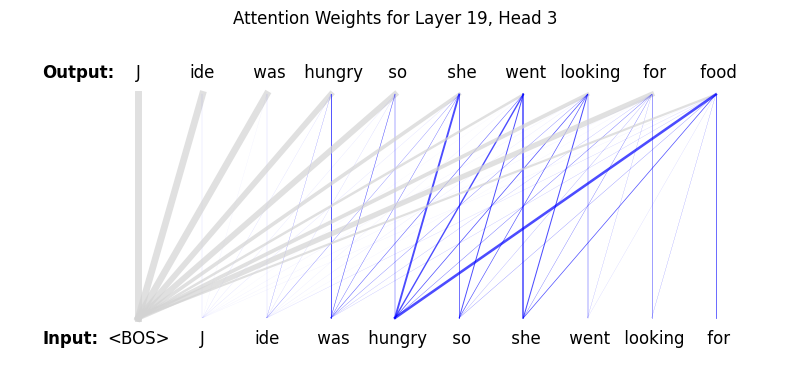

In [30]:
# @title Visualize attention weights (your implementation)
layer = 19  # @param {type:"slider", min: 0, max: 25}
head = 3  # @param {type:"slider", min: 0, max: 3}

prompt = "Jide was hungry so she went looking for"  # @param {type: 'string'}
# @markdown Check the following box to display the attention weights for all tokens, not just for the generated one:
show_all_weights = True  # @param {type:"boolean", label: "sfdsf"}

model_name = "Gemma-1B"

if prompt != previous_prompt2:
    (
        output_text2,
        next_token_logits2,
        tokenizer,
        attention_weights2,
        attention_mask2,
        qkv_dict2,
    ) = generation.prompt_attention_transformer_model(
        prompt, model, sampling_mode="greedy"
    )
    tokens2 = [tokenizer.tokens[t] for t in tokenizer.encode(output_text2)]
    previous_prompt2 = prompt

print(f"Generated text: {output_text2}")

attn_out, attn_weights = compute_attention(qkv_dict2, layer)

visualizations.visualize_attention(
    tokens2,
    attn_weights,
    layer,
    head=head,
    min_line_thickness=0,
    max_line_thickness=5,
    show_all_weights=show_all_weights,
)